In [1]:
#Basic libraries
import numpy as np
import pandas as pd

#Visualization Libraries
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

#Evaluation Libraries
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

#Deep Learning Libraries
import tensorflow as tf
from tensorflow.keras import layers
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Flatten,Conv2D,MaxPooling2D
# from keras.layers.core import Dense,Activation,Dropout
from keras.datasets import mnist
from keras import utils as np_utils
from keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier
# from keras.wrappers.scikit_learn import KerasClassifier


In [2]:
#Load digitmnist dataset
(X_train,y_train),(X_test,y_test) = mnist.load_data()

In [3]:
X_train.shape
#60000 - 60000 images each image with 28RX28C

(60000, 28, 28)

In [4]:
X_test.shape

(10000, 28, 28)

In [5]:
X_train = X_train.reshape(X_train.shape[0],28,28,1) #flatterning the rows and columns of the matrix
X_test = X_test.reshape(X_test.shape[0],28,28,1)
input_shape = (28,28,1)

In [6]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [7]:
X_train/=255
X_test/=255

In [11]:
X_train.shape

(60000, 28, 28, 1)

In [12]:
y_train.shape

(60000,)

In [8]:
model = Sequential()
model.add(Conv2D(28,kernel_size=(3,3),input_shape = input_shape))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation = 'relu')) #model.add(Dense(128,activation = tf.nn.relu))
model.add(Dropout(0.2))
model.add(Dense(10,activation = 'softmax'))#model.add(Dense(128,activation = tf.nn.softmax))

C:\Users\SAIRAM\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
#compiling the model - https://keras.io/api/
model.compile(optimizer = "adam",loss = "sparse_categorical_crossentropy",
             metrics=['accuracy'])
model.fit(x=X_train,y = y_train,epochs= 10)
#why 1875 means in keras Batch Size: 32 (Keras default) Calculation: 60000/32 = 1875
# If epoch increases accuracy also increases loss will be decreased...

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9360 - loss: 0.2142
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9737 - loss: 0.0878
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9802 - loss: 0.0631
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9862 - loss: 0.0451
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9879 - loss: 0.0369
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9894 - loss: 0.0312
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9912 - loss: 0.0258
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9926 - loss: 0.0223
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9929 - loss: 0.0197
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9940 - loss: 0.0172


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 28)          │             280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 28)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4732)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         605,824 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,822,184 (6.95 MB)

 Trainable params: 607,394 (2.32 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,214,790 (4.63 MB)

In [13]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9851 - loss: 0.0676


[0.06763079762458801, 0.9850999712944031]

In [14]:
y_predict = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [15]:
y_predict

array([[1.9885977e-11, 1.1231526e-13, 2.0233606e-11, ..., 1.0000000e+00,
        1.4383546e-13, 3.9928411e-10],
       [3.8376591e-10, 4.4485884e-10, 1.0000000e+00, ..., 3.2419303e-18,
        3.6169298e-15, 1.9496932e-21],
       [3.0390243e-10, 9.9999976e-01, 6.0876062e-08, ..., 2.6645948e-09,
        1.2087442e-07, 9.6819612e-13],
       ...,
       [1.6035207e-24, 2.0270475e-17, 4.6409930e-21, ..., 7.6829119e-13,
        3.6360606e-12, 1.0127392e-12],
       [3.4207698e-16, 9.0272153e-17, 1.1431833e-21, ..., 1.4233199e-17,
        5.0382145e-08, 8.4606389e-17],
       [9.0360879e-12, 3.8926094e-17, 2.4684912e-09, ..., 1.1892561e-15,
        9.9270917e-13, 9.2703174e-15]], shape=(10000, 10), dtype=float32)

In [16]:
y_predicts = np.argmax(y_predict,axis = 1)

In [17]:
y_predicts

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [19]:
y_test

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

[[ 975    1    0    0    0    0    2    1    1    0]
 [   0 1126    3    0    0    1    1    1    3    0]
 [   2    1 1018    0    1    0    1    5    3    1]
 [   0    0    3  993    0    5    0    6    2    1]
 [   0    0    2    0  974    0    3    0    0    3]
 [   3    0    0    3    0  883    3    0    0    0]
 [   7    2    1    1    2    6  936    0    3    0]
 [   1    1    8    1    2    0    0 1011    3    1]
 [   5    0    1    4    2    3    0    4  951    4]
 [   1    2    0    3    9    5    0    2    3  984]]


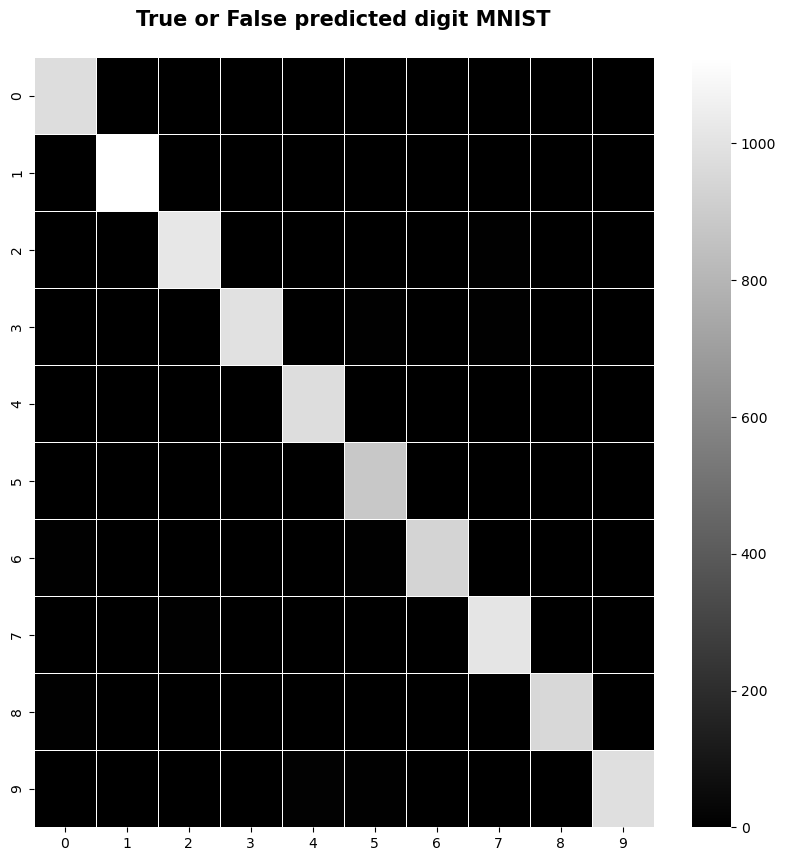

In [24]:
#confusion matrix for Digit Mnist
con_mat = confusion_matrix(y_test,y_predicts)
print(con_mat)
plt.style.use('seaborn-v0_8-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot_kws={'size':15},linewidth=0.5,fmt ='d',cmap ='grey')
plt.title('True or False predicted digit MNIST\n',fontweight='bold',fontsize=15)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


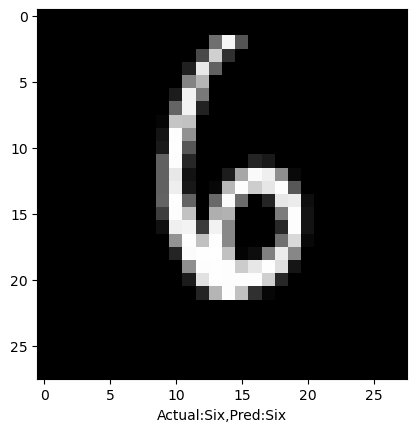

In [23]:
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']
image_index = 6900
y_predict_single = model.predict(X_test[[image_index]])
y_predicts_single = np.argmax(y_predict_single,axis=1)
#visulaize the digits
plt.imshow(X_test[image_index].reshape(28,28),cmap ='gray')
plt.xlabel("Actual:{},Pred:{}".format(col_names[y_test[image_index]],col_names[y_predicts_single[0]]))
plt.show()